In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
from tensorflow.keras.layers import Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = [
    "deep learning is fun",
    "deep learning is powerful",
    "machine learning is interesting",
    "artificial intelligence is the future",
    "data science is amazing",
    "neural networks learn patterns",
    "python is useful for machine learning",
    "tensorflow makes deep learning easy",
    "practice improves coding skills"
]

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data)

In [ ]:
total_words = len(tokenizer.word_index) + 1
total_words

29

In [ ]:
input_seq = []
for line in data:
  seq = tokenizer.texts_to_sequences([line])[0]
  for i in range(1, len(seq)):
    input_seq.append(seq[:i+1])
input_seq

[[3, 2],
 [3, 2, 1],
 [3, 2, 1, 5],
 [3, 2],
 [3, 2, 1],
 [3, 2, 1, 6],
 [4, 2],
 [4, 2, 1],
 [4, 2, 1, 7],
 [8, 9],
 [8, 9, 1],
 [8, 9, 1, 10],
 [8, 9, 1, 10, 11],
 [12, 13],
 [12, 13, 1],
 [12, 13, 1, 14],
 [15, 16],
 [15, 16, 17],
 [15, 16, 17, 18],
 [19, 1],
 [19, 1, 20],
 [19, 1, 20, 21],
 [19, 1, 20, 21, 4],
 [19, 1, 20, 21, 4, 2],
 [22, 23],
 [22, 23, 3],
 [22, 23, 3, 2],
 [22, 23, 3, 2, 24],
 [25, 26],
 [25, 26, 27],
 [25, 26, 27, 28]]

In [ ]:
max_len = max(len(x) for x in input_seq)
input_seq = pad_sequences(input_seq, maxlen=max_len, padding='pre')
input_seq

array([[ 0,  0,  0,  0,  3,  2],
       [ 0,  0,  0,  3,  2,  1],
       [ 0,  0,  3,  2,  1,  5],
       [ 0,  0,  0,  0,  3,  2],
       [ 0,  0,  0,  3,  2,  1],
       [ 0,  0,  3,  2,  1,  6],
       [ 0,  0,  0,  0,  4,  2],
       [ 0,  0,  0,  4,  2,  1],
       [ 0,  0,  4,  2,  1,  7],
       [ 0,  0,  0,  0,  8,  9],
       [ 0,  0,  0,  8,  9,  1],
       [ 0,  0,  8,  9,  1, 10],
       [ 0,  8,  9,  1, 10, 11],
       [ 0,  0,  0,  0, 12, 13],
       [ 0,  0,  0, 12, 13,  1],
       [ 0,  0, 12, 13,  1, 14],
       [ 0,  0,  0,  0, 15, 16],
       [ 0,  0,  0, 15, 16, 17],
       [ 0,  0, 15, 16, 17, 18],
       [ 0,  0,  0,  0, 19,  1],
       [ 0,  0,  0, 19,  1, 20],
       [ 0,  0, 19,  1, 20, 21],
       [ 0, 19,  1, 20, 21,  4],
       [19,  1, 20, 21,  4,  2],
       [ 0,  0,  0,  0, 22, 23],
       [ 0,  0,  0, 22, 23,  3],
       [ 0,  0, 22, 23,  3,  2],
       [ 0, 22, 23,  3,  2, 24],
       [ 0,  0,  0,  0, 25, 26],
       [ 0,  0,  0, 25, 26, 27],
       [ 0

In [ ]:
X = input_seq[:, : -1]
y = input_seq[:, -1]

In [ ]:
from keras.models import Sequential
model = Sequential()

In [ ]:
from keras.layers import LSTM

In [ ]:
model.add(Embedding(total_words, 29, input_length=max_len-1)),
model.add(LSTM(100)),
model.add(Dense(total_words, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history = model.fit(X, y, epochs = 300, validation_split=0.2 ,verbose = 1)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9583 - loss: 0.0615 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9583 - loss: 0.0615 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9583 - loss: 0.0614 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9583 - loss: 0.0614 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9583 - loss: 0.0614 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9583 - loss: 0.0613 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9583 - loss: 0.0613 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9583 - loss: 0.0612 - val_accuracy: 1.0000 - val_

In [ ]:
print("Training accuracy: ", history.history['accuracy'][-1])
print("Validation accuracy: ", history.history['val_accuracy'][-1])

Training accuracy:  0.9583333134651184
Validation accuracy:  1.0


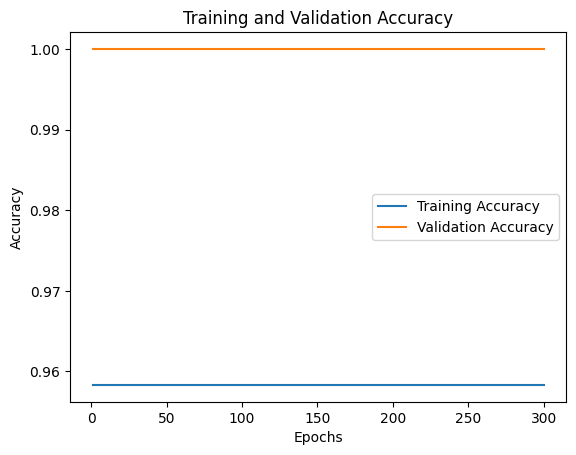

In [ ]:
epochs = range(1, len(history.history['accuracy']) + 1)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

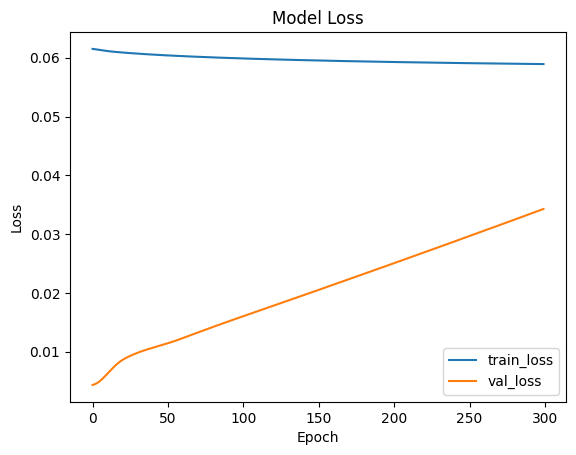

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
def generate_text(start_text, n_words):
  text = start_text
  for i in range(n_words):
    seq = tokenizer.texts_to_sequences([text])[0]
    seq = pad_sequences([seq], maxlen = max_len-1, padding = 'pre')
    pred = model.predict(seq)
    pred = np.argmax(pred)
    for word, index in tokenizer.word_index.items():
      if index == pred:
        text += " " + word
        break
  return text
print(generate_text("deep learning", 2))
print(generate_text("machine learning", 2))
print(generate_text("artificial intelligence", 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
deep learning is powerful
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
machine learning is interesting
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
artificial intelligence is the future
